# 03 — Analyse exploratoire & statistiques

Objectif : mettre en évidence les tendances (pays dominants, parité, effet de masse) et appuyer les observations par des **indicateurs statistiques** (Gini, χ², Pearson).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Racine projet :', ROOT)

Racine projet : C:\Users\nicol\ynov\Fil Rouge\Projet-Fil-Rouge-J.O


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
from src.data.data_loader import load_raw_data
from src.data.data_cleaner import clean_data
from src.analysis import statistics as stx

df = clean_data(load_raw_data())
medals = df[df['Medal'].isin(['Gold', 'Silver', 'Bronze'])]
print('Lignes médaillées :', len(medals))

Lignes médaillées : 38818


## Pays dominants — score pondéré (Or=3, Argent=2, Bronze=1)

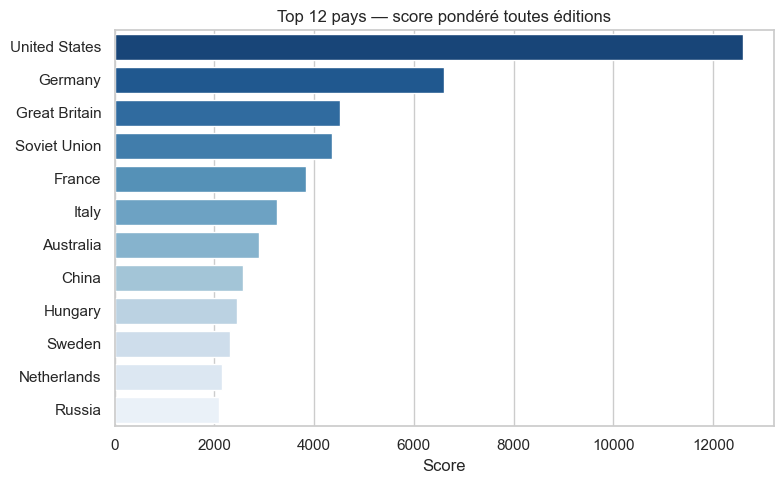

,NOC,Team,Score
0,USA,United States,12592
1,GER,Germany,6611
2,GBR,Great Britain,4527
3,URS,Soviet Union,4362
4,FRA,France,3833


In [3]:
score = stx.weighted_medal_score(df).head(12)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=score, y='Team', x='Score', hue='Team', palette='Blues_r', legend=False, ax=ax)
ax.set_title('Top 12 pays — score pondéré toutes éditions'); ax.set_ylabel('')
plt.tight_layout(); plt.show()
score.head()

## Concentration des médailles — indice de Gini

Mesure l'inégalité de répartition des médailles entre pays (0 = égalité, 1 = monopole).

In [4]:
gini = stx.medal_concentration_gini(df)
print(f'Indice de Gini : {gini:.3f}')

Indice de Gini : 0.821


## Évolution de la parité hommes / femmes

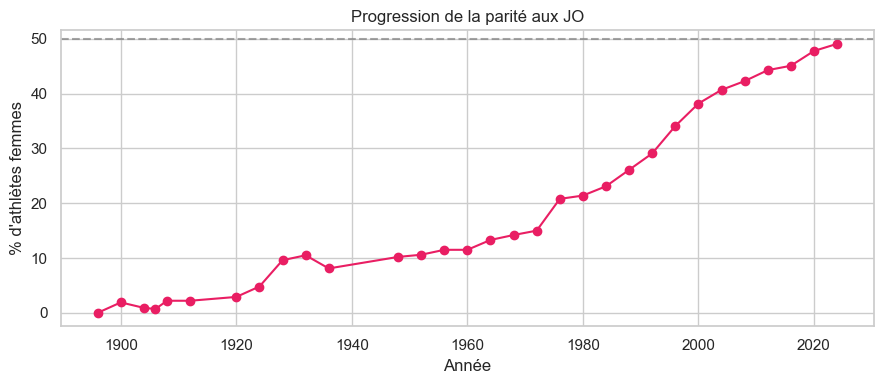

In [5]:
parity = stx.gender_parity_over_time(df)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(parity['Year'], parity['pct_femmes'], marker='o', color='#E91E63')
ax.axhline(50, ls='--', color='gray', alpha=0.7)
ax.set_ylabel('% d\'athlètes femmes'); ax.set_xlabel('Année')
ax.set_title('Progression de la parité aux JO'); plt.tight_layout(); plt.show()

## Test inférentiel : genre et obtention d'une médaille (χ²)

H₀ : remporter une médaille est **indépendant** du genre.

In [6]:
res = stx.chi2_sex_medal(df)
print('χ² =', round(res['chi2'], 2), '| p-value =', res['p_value'])
print('Dépendance significative au seuil 5 % :', res['significant_5pct'])

χ² =

 25.9 | p-value = 3.6017604479140986e-07
Dépendance significative au seuil 5 % : True


## Effet de masse : athlètes envoyés vs médailles gagnées

Corrélation de Pearson : 0.857 | p = 0.0


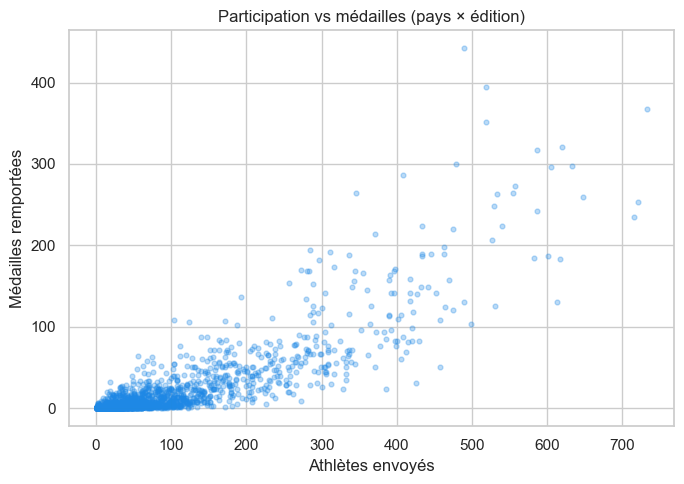

In [7]:
res = stx.corr_participation_medals(df)
print('Corrélation de Pearson :', round(res['pearson_r'], 3), '| p =', res['p_value'])
grp = (df.groupby(['NOC', 'Year'])
         .agg(athletes=('Name', 'nunique'),
              medals=('Medal', lambda s: s.isin(['Gold', 'Silver', 'Bronze']).sum()))
         .reset_index())
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(grp['athletes'], grp['medals'], alpha=0.3, s=12, color='#1E88E5')
ax.set_xlabel('Athlètes envoyés'); ax.set_ylabel('Médailles remportées')
ax.set_title('Participation vs médailles (pays × édition)'); plt.tight_layout(); plt.show()

## Conclusion

- Les médailles sont **très concentrées** (Gini élevé) : une poignée de nations domine.
- Le lien genre / médaille est **statistiquement significatif** (χ², p < 0,05).
- **Forte corrélation** entre le nombre d'athlètes envoyés et les médailles : variable clé pour la modélisation.
- La parité progresse nettement et s'approche de 50 % sur les éditions récentes.